[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-2/trim-filter-messages.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58239435-lesson-4-trim-and-filter-messages)

# Filtering and trimming messages

## Review

Now, we have a deeper understanding of a few things: 

* How to customize the graph state schema
* How to define custom state reducers
* How to use multiple graph state schemas

## Goals

Now, we can start using these concepts with models in LangGraph!
 
In the next few sessions, we'll build towards a chatbot that has long-term memory.

Because our chatbot will use messages, let's first talk a bit more about advanced ways to work with messages in graph state.

In [ ]:
%%capture --no-stderr
%pip install --quiet -U langchain_core langgraph langchain_openai

__name__ = "__main__"

In [1]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

if "OPENAI_API_KEY" not in os.environ:
    _set_env("OPENAI_API_KEY")

if "OPEN_ROUTER_API_KEY" not in os.environ:
    _set_env("OPEN_ROUTER_API_KEY")

We'll use [LangSmith](https://docs.langchain.com/langsmith/home) for [tracing](https://docs.langchain.com/langsmith/observability-concepts).

We'll log to a project, `langchain-academy`. 

In [2]:
_set_env("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "langchain-academy"

## Messages as state

First, let's define some messages.

In [3]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

messages = [AIMessage(f"So you said you were researching ocean mammals?", name="Bot")]
messages.append(HumanMessage(f"Yes, I know about whales. But what others should I learn about?", name="Lance"))

for m in messages:
    m.pretty_print()

messages

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?


[AIMessage(content='So you said you were researching ocean mammals?', additional_kwargs={}, response_metadata={}, name='Bot', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Yes, I know about whales. But what others should I learn about?', additional_kwargs={}, response_metadata={}, name='Lance')]

Recall we can pass them to a chat model.

In [6]:
from langchain_openai import ChatOpenAI
# llm = ChatOpenAI(model="gpt-4o")
llm = ChatOpenAI(
    api_key=os.environ["OPEN_ROUTER_API_KEY"],
    base_url="https://openrouter.ai/api/v1",
    # model="openai/gpt-oss-120b:free",       # OpenAI: gpt-oss-120b (free)
                                            # Free Users with $10+ in credits
                                            # - 1,000 requests per day
                                            # - 20 requests per minute
    model="openai/gpt-oss-120b",            # OpenAI: gpt-oss-120b (paid)
                                            # $0.039/M input, $0.19/M output
    temperature=0,
    default_headers={
        "HTTP-Referer": "localhost",  # Optional. Site URL for rankings on openrouter.ai.
        "X-Title": "langchain-academy",  # Optional. Site title for rankings on openrouter.ai.
    },
    extra_body={
        "provider": {
            "sort": "latency",           # prioritize lowest latency providers
            "allow_fallbacks": True,     # fall back to others if unavailable
        }
    }
)

llm.invoke(messages)

AIMessage(content='### Beyond Whales: A Quick‑Start Guide to the Other Ocean Mammals\n\n| Group | Iconic Species | Where You’ll Find Them | Fun Fact or Two |\n|-------|----------------|------------------------|-----------------|\n| **Dolphins & Porpoises** | Bottlenose dolphin, Common dolphin, Harbor porpoise | Coastal waters, open ocean, rivers (e.g., Amazon river dolphin) | • Dolphins have a “signature whistle” that works like a name.<br>• Porpoises are generally smaller and have a more rounded head than dolphins. |\n| **Pinnipeds** (seal‑like carnivores) | **Seals** (e.g., Harbor seal), **Sea lions** (e.g., California sea lion), **Walrus** | Rocky shores, ice floes, temperate to polar coasts | • Sea lions can “walk” on land using their front flippers.<br>• Walruses have the longest tusks of any mammal—up to 1\u202fm! |\n| **Sea Otters** | Northern sea otter, Southern sea otter | Kelp forests along the North Pacific coast | • They use rocks as “tools” to crack open shellfish.<br>• Th

We can run our chat model in a simple graph with `MessagesState`.

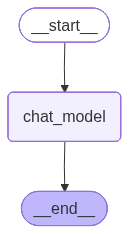

In [7]:
from IPython.display import Image, display
from langgraph.graph import MessagesState
from langgraph.graph import StateGraph, START, END

# Node
def chat_model_node(state: MessagesState):
    return {"messages": llm.invoke(state["messages"])}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)

builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)

graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
output = graph.invoke({'messages': messages})

for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

### Beyond Whales: A Quick Guide to Other Ocean (Marine) Mammals

| Group | Iconic Species | Key Traits | Where to Find Them |
|-------|----------------|------------|--------------------|
| **Dolphins & Porpoises** | Bottlenose Dolphin, Common Dolphin, Harbor Porpoise | Highly social, use echolocation, often ride bow‑waves. | Temperate & tropical coastal waters worldwide; many protected marine parks have dolphin‑watch programs. |
| **Pinnipeds** (seal‑like) | **Seals** – Harbor Seal, Elephant Seal  <br>**Sea Lions** – California Sea Lion, Steller Sea Lion  <br>**Walrus** – Pacific Walrus | Front flippers for “wal

## Reducer

A practical challenge when working with messages is managing long-running conversations. 

Long-running conversations result in high token usage and latency if we are not careful, because we pass a growing list of messages to the model.

We have a few ways to address this.

First, recall the trick we saw using `RemoveMessage` and the `add_messages` reducer.

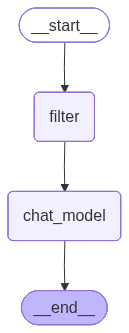

In [9]:
from langchain_core.messages import RemoveMessage

# Nodes
def filter_messages(state: MessagesState):
    print("messages before filter:")
    for m in state['messages']:
        m.pretty_print()
    # Delete all but the 2 most recent messages
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"messages": delete_messages}

def chat_model_node(state: MessagesState):    
    print("messages after filter:")
    for m in state['messages']:
        m.pretty_print()
    return {"messages": [llm.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("filter", filter_messages)
builder.add_node("chat_model", chat_model_node)

builder.add_edge(START, "filter")
builder.add_edge("filter", "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
# Message list with a preamble
messages = [AIMessage("Hi.", name="Bot", id="1")]
messages.append(HumanMessage("Hi.", name="Lance", id="2"))
messages.append(AIMessage("So you said you were researching ocean mammals?", name="Bot", id="3"))
messages.append(HumanMessage("Yes, I know about whales. But what others should I learn about?", name="Lance", id="4"))

# Invoke
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

messages

messages before filter:
================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Lance

Hi.
================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
messages after filter:
================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
=======================

[AIMessage(content='Hi.', additional_kwargs={}, response_metadata={}, name='Bot', id='1', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Hi.', additional_kwargs={}, response_metadata={}, name='Lance', id='2'),
 AIMessage(content='So you said you were researching ocean mammals?', additional_kwargs={}, response_metadata={}, name='Bot', id='3', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Yes, I know about whales. But what others should I learn about?', additional_kwargs={}, response_metadata={}, name='Lance', id='4')]

## Filtering messages

If you don't need or want to modify the graph state, you can just filter the messages you pass to the chat model.

For example, just pass in a filtered list: `llm.invoke(messages[-1:])` to the model.

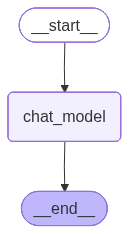

In [18]:
# Node
def chat_model_node(state: MessagesState):
    return {"messages": [llm.invoke([
        state["messages"][:].pop()
        ])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)

builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

Let's take our existing list of messages, append the above LLM response, and append a follow-up question.

In [19]:
messages.append(output['messages'][-1])
messages.append(HumanMessage(f"Tell me more about Narwhals!", name="Lance"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Lance

Hi.
================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

### Beyond Whales: A Quick‑Start Guide to the Other Ocean Mammals

| Group | Iconic Species | Where You’ll Find Them | Fun Fact or Why They’re Cool |
|-------|----------------|------------------------|------------------------------|
| **Dolphins & Porpoises** | Bottlenose dolphin, Common dolphin, Harbor porpoise | Coastal waters, open ocean, rivers (some river dolphins) | Dolphins have a “signature whistle” that works like

In [20]:
messages

[AIMessage(content='Hi.', additional_kwargs={}, response_metadata={}, name='Bot', id='1', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Hi.', additional_kwargs={}, response_metadata={}, name='Lance', id='2'),
 AIMessage(content='So you said you were researching ocean mammals?', additional_kwargs={}, response_metadata={}, name='Bot', id='3', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Yes, I know about whales. But what others should I learn about?', additional_kwargs={}, response_metadata={}, name='Lance', id='4'),
 AIMessage(content='### Beyond Whales: A Quick‑Start Guide to the Other Ocean Mammals\n\n| Group | Iconic Species | Where You’ll Find Them | Fun Fact or Why They’re Cool |\n|-------|----------------|------------------------|------------------------------|\n| **Dolphins & Porpoises** | Bottlenose dolphin, Common dolphin, Harbor porpoise | Coastal waters, open ocean, rivers (some river dolphins) | Dolphins have a “signature whistle” that works 

In [21]:
# Invoke, using message filtering
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Lance

Hi.
================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

### Beyond Whales: A Quick‑Start Guide to the Other Ocean Mammals

| Group | Iconic Species | Where You’ll Find Them | Fun Fact or Why They’re Cool |
|-------|----------------|------------------------|------------------------------|
| **Dolphins & Porpoises** | Bottlenose dolphin, Common dolphin, Harbor porpoise | Coastal waters, open ocean, rivers (some river dolphins) | Dolphins have a “signature whistle” that works like

In [22]:
messages

[AIMessage(content='Hi.', additional_kwargs={}, response_metadata={}, name='Bot', id='1', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Hi.', additional_kwargs={}, response_metadata={}, name='Lance', id='2'),
 AIMessage(content='So you said you were researching ocean mammals?', additional_kwargs={}, response_metadata={}, name='Bot', id='3', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Yes, I know about whales. But what others should I learn about?', additional_kwargs={}, response_metadata={}, name='Lance', id='4'),
 AIMessage(content='### Beyond Whales: A Quick‑Start Guide to the Other Ocean Mammals\n\n| Group | Iconic Species | Where You’ll Find Them | Fun Fact or Why They’re Cool |\n|-------|----------------|------------------------|------------------------------|\n| **Dolphins & Porpoises** | Bottlenose dolphin, Common dolphin, Harbor porpoise | Coastal waters, open ocean, rivers (some river dolphins) | Dolphins have a “signature whistle” that works 

The state has all of the mesages.

But, let's look at the LangSmith trace to see that the model invocation only uses the last message:

https://smith.langchain.com/public/75aca3ce-ef19-4b92-94be-0178c7a660d9/r

## Trim messages

Another approach is to [trim messages](https://docs.langchain.com/oss/python/langgraph/add-memory#trim-messages), based upon a set number of tokens. 

This restricts the message history to a specified number of tokens.

While filtering only returns a post-hoc subset of the messages between agents, trimming restricts the number of tokens that a chat model can use to respond.

See the `trim_messages` below.

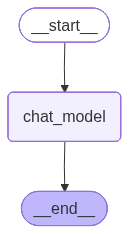

In [23]:
from langchain_core.messages import trim_messages

# Node
def chat_model_node(state: MessagesState):
    messages = trim_messages(
            state["messages"],
            max_tokens=100,
            strategy="last",
            token_counter=ChatOpenAI(model="gpt-4o"),
            allow_partial=False,
        )
    return {"messages": [llm.invoke(messages)]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [26]:
messages.append(output['messages'][-1])
messages.append(HumanMessage(f"Tell me where Orcas live!", name="Lance"))

In [27]:
# Example of trimming messages
trim_messages(
            messages,
            max_tokens=100,
            strategy="last",
            token_counter=ChatOpenAI(model="gpt-4o"),
            allow_partial=False
        )

[HumanMessage(content='Tell me where Orcas live!', additional_kwargs={}, response_metadata={}, name='Lance')]

In [30]:
# Invoke, using message trimming in the chat_model_node 
messages_out_trim = graph.invoke({'messages': messages})

Let's look at the LangSmith trace to see the model invocation:

https://smith.langchain.com/public/b153f7e9-f1a5-4d60-8074-f0d7ab5b42ef/r